In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
experiments = {
    "IID 10 nodos":       "outputs/2026-03-02_16-15-57/metrics.json",
    "IID 20 nodos":       "outputs/2026-03-02_16-17-27/metrics.json",
    "IID 50 nodos":       "outputs/2026-03-02_16-18-58/metrics.json",
    "Dirichlet α=1.0":    "outputs/2026-03-02_16-20-27/metrics.json",
    "Dirichlet α=0.1":    "outputs/2026-03-02_16-22-05/metrics.json",
    "Pathological 2 cls": "outputs/2026-03-02_16-23-44/metrics.json",
    "Pathological 5 cls": "outputs/2026-03-02_16-25-33/metrics.json",
}

data = {}
for name, path in experiments.items():
    with open(path) as f:
        metrics = json.load(f)
    rounds = sorted([int(k) for k in metrics.keys() if int(k) > 0])
    data[name] = {
        "rounds": rounds,
        "accuracy": [metrics[str(r)]["accuracy"] for r in rounds],
        "loss":     [metrics[str(r)]["loss"] for r in rounds],
    }

print("Datos cargados ✅")
for name, d in data.items():
    print(f"{name}: accuracy final = {d['accuracy'][-1]:.4f}")

Datos cargados ✅
IID 10 nodos: accuracy final = 0.8760
IID 20 nodos: accuracy final = 0.8364
IID 50 nodos: accuracy final = 0.7575
Dirichlet α=1.0: accuracy final = 0.7621
Dirichlet α=0.1: accuracy final = 0.3818
Pathological 2 cls: accuracy final = 0.4502
Pathological 5 cls: accuracy final = 0.8255


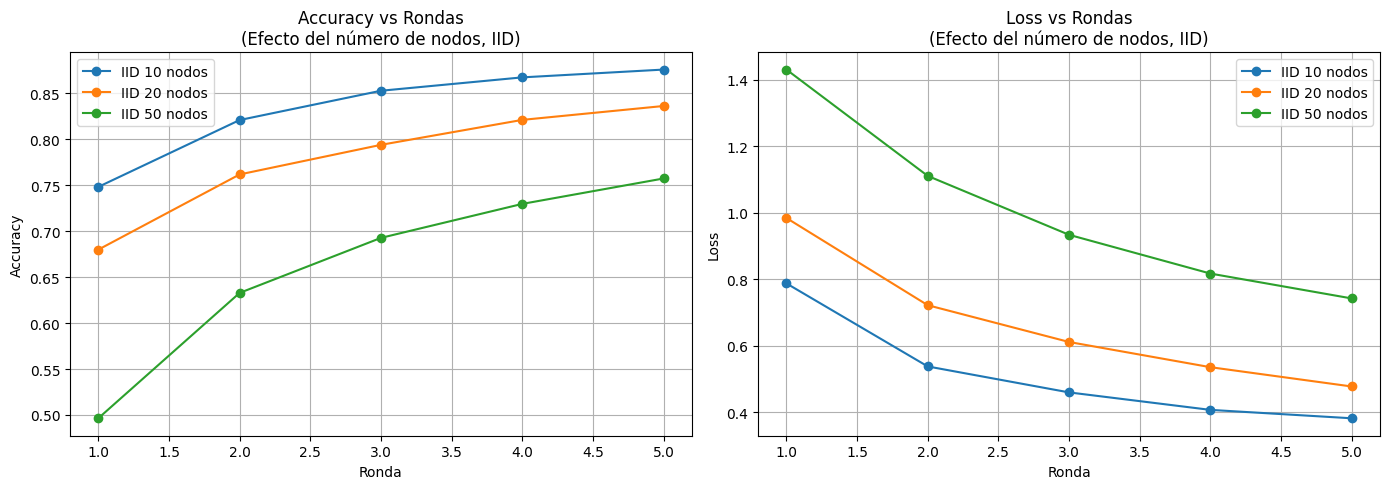

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name in ["IID 10 nodos", "IID 20 nodos", "IID 50 nodos"]:
    d = data[name]
    ax1.plot(d["rounds"], d["accuracy"], marker="o", label=name)
    ax2.plot(d["rounds"], d["loss"], marker="o", label=name)

ax1.set_title("Accuracy vs Rondas\n(Efecto del número de nodos, IID)")
ax1.set_xlabel("Ronda")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

ax2.set_title("Loss vs Rondas\n(Efecto del número de nodos, IID)")
ax2.set_xlabel("Ronda")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("plot_nodes.png", dpi=150)
plt.show()

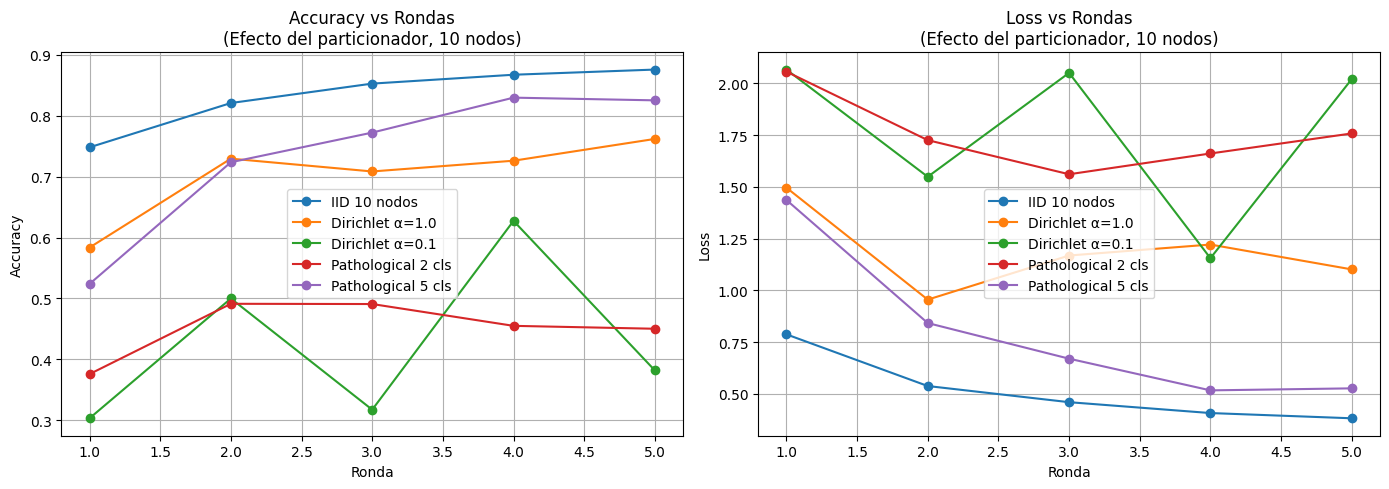

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name in ["IID 10 nodos", "Dirichlet α=1.0", "Dirichlet α=0.1",
             "Pathological 2 cls", "Pathological 5 cls"]:
    d = data[name]
    ax1.plot(d["rounds"], d["accuracy"], marker="o", label=name)
    ax2.plot(d["rounds"], d["loss"], marker="o", label=name)

ax1.set_title("Accuracy vs Rondas\n(Efecto del particionador, 10 nodos)")
ax1.set_xlabel("Ronda")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

ax2.set_title("Loss vs Rondas\n(Efecto del particionador, 10 nodos)")
ax2.set_xlabel("Ronda")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("plot_partitioners.png", dpi=150)
plt.show()

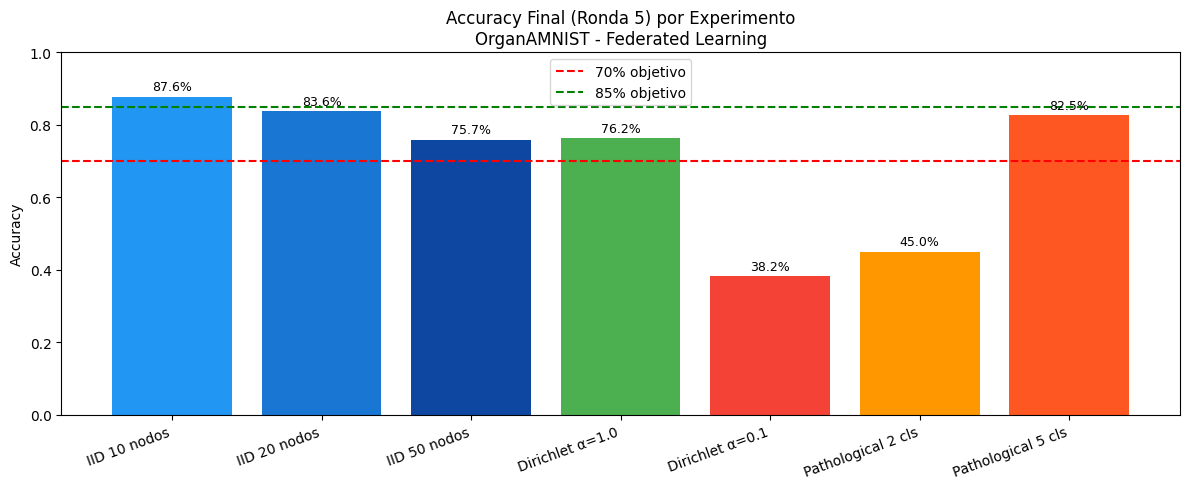

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

names = list(data.keys())
final_acc = [data[n]["accuracy"][-1] for n in names]
colors = ["#2196F3", "#1976D2", "#0D47A1",
          "#4CAF50", "#F44336", "#FF9800", "#FF5722"]

bars = ax.bar(names, final_acc, color=colors)
ax.set_title("Accuracy Final (Ronda 5) por Experimento\nOrganAMNIST - Federated Learning")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.0)
ax.axhline(y=0.7, color="red", linestyle="--", label="70% objetivo")
ax.axhline(y=0.85, color="green", linestyle="--", label="85% objetivo")

for bar, acc in zip(bars, final_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{acc:.1%}", ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=20, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig("plot_final_comparison.png", dpi=150)
plt.show()